# Asian Option Extension 2 under the Replicated SABR Simulator

This notebook turns the Asian option extension into a more complete numerical experiment rather than a surface-level payoff example.

The underlying simulator follows the same paper machinery used elsewhere in the project:

1. exact lognormal stepping of the SABR volatility process;
2. Algorithm 1 shifted-lognormal sampling of the conditional average variance $I_t^h$;
3. Algorithm 2 martingale-preserving CEV approximation of $F_{t+h}$;
4. Algorithm 3 exact CEV sampling through the shifted Poisson-mixture gamma representation.

The new object priced here is a discretely monitored arithmetic Asian call:

$$
\left(A_T - K\right)^+, \qquad
A_T = \frac{1}{M}\sum_{i=1}^{M}F_{t_i}, \qquad t_i = iT/M.
$$

All prices in this notebook are undiscounted forward-measure Monte Carlo values. A market present value can be obtained by multiplying by the appropriate discount factor.


## 1. Environment and imports

The notebook is self-contained. It only assumes that it is run from the project root or from a `notebooks/` folder under the project root.


In [1]:
from __future__ import annotations

from pathlib import Path
import importlib
import math
import os
import platform
import sys
import tempfile
import time

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'matplotlib-cache'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.options.display.float_format = '{:.6f}'.format
plt.rcParams.update({
    'figure.figsize': (8, 4.6),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('Project root:', PROJECT_ROOT)
for pkg in ['numpy', 'pandas', 'matplotlib', 'pyfeng']:
    mod = importlib.import_module(pkg)
    print(f'{pkg}:', getattr(mod, '__version__', 'version unavailable'))


Python: 3.13.9
Platform: macOS-15.5-arm64-arm-64bit-Mach-O
Project root: /Users/zhengchao/Downloads/数值分析project
numpy: 2.4.1
pandas: 3.0.0
matplotlib: 3.10.8


pyfeng: version unavailable


In [2]:
from sabr_replicate import (
    EPS,
    PDF_FLOOR,
    MonteCarloConfig,
    SABRParams,
    _correlated_drift_term,
    european_call_price,
    sample_cev_exact,
    sample_conditional_integrated_variance,
    sample_sigma_next,
    simulate_terminal_forward,
)


## 2. Contract and estimator helpers

The contract convention is intentionally explicit:

- arithmetic average over future monitoring dates only by default;
- no discounting inside the payoff;
- the expected arithmetic average should be close to $F_0$ because the simulated forward is designed to preserve the martingale property.

That last point gives a useful control variate: since $E[A_T] = F_0$, the variable $A_T - F_0$ can reduce the Monte Carlo standard error of the Asian payoff.


In [3]:
class AsianContract:
    def __init__(self, maturity: float, strike: float, n_monitoring: int, include_initial: bool = False):
        self.maturity = maturity
        self.strike = strike
        self.n_monitoring = n_monitoring
        self.include_initial = include_initial
        self.step = maturity / n_monitoring
        self.average_denominator = n_monitoring + int(include_initial)


class AsianPathSamples:
    def __init__(
        self,
        terminal: np.ndarray,
        arithmetic_average: np.ndarray,
        runtime_sec: float,
        absorbed_fraction: float,
    ):
        self.terminal = terminal
        self.arithmetic_average = arithmetic_average
        self.runtime_sec = runtime_sec
        self.absorbed_fraction = absorbed_fraction


def mean_estimate(samples: np.ndarray, expected: float | None = None) -> dict[str, float]:
    samples = np.asarray(samples, dtype=float)
    mean = float(np.mean(samples))
    stderr = float(np.std(samples, ddof=1) / math.sqrt(samples.size))
    out = {
        'mean': mean,
        'stderr': stderr,
        'ci95_low': mean - 1.96 * stderr,
        'ci95_high': mean + 1.96 * stderr,
    }
    if expected is not None:
        out['expected'] = float(expected)
        out['z_score'] = float((mean - expected) / stderr) if stderr > 0 else np.nan
    return out


def call_payoff(underlying: np.ndarray, strike: float) -> np.ndarray:
    return np.maximum(np.asarray(underlying, dtype=float) - strike, 0.0)


def mc_price_from_payoff(payoff: np.ndarray) -> dict[str, float]:
    payoff = np.asarray(payoff, dtype=float)
    price = float(np.mean(payoff))
    stderr = float(np.std(payoff, ddof=1) / math.sqrt(payoff.size))
    return {
        'price': price,
        'stderr': stderr,
        'ci95_low': price - 1.96 * stderr,
        'ci95_high': price + 1.96 * stderr,
    }


def asian_price_raw(average: np.ndarray, strike: float) -> dict[str, float]:
    return mc_price_from_payoff(call_payoff(average, strike))


def asian_price_with_average_control(
    average: np.ndarray,
    strike: float,
    expected_average: float,
) -> dict[str, float]:
    payoff = call_payoff(average, strike)
    control = np.asarray(average, dtype=float) - expected_average
    control_var = float(np.var(control, ddof=1))
    if control_var <= 0.0:
        base = mc_price_from_payoff(payoff)
        base.update({'beta_cv': 0.0, 'stderr_reduction': 1.0})
        return base

    beta_cv = float(np.cov(payoff, control, ddof=1)[0, 1] / control_var)
    adjusted = payoff - beta_cv * control
    cv = mc_price_from_payoff(adjusted)
    raw = mc_price_from_payoff(payoff)
    cv.update({
        'beta_cv': beta_cv,
        'raw_stderr': raw['stderr'],
        'stderr_reduction': raw['stderr'] / cv['stderr'] if cv['stderr'] > 0 else np.inf,
    })
    return cv


def european_price_estimate(terminal: np.ndarray, strike: float) -> dict[str, float]:
    return mc_price_from_payoff(call_payoff(terminal, strike))


## 3. Path simulator using the paper transition

The original project function `simulate_terminal_forward` returns only $F_T$. For an Asian payoff, we need the running arithmetic average. The function below repeats the paper one-step transition and records the average along the monitoring grid.

A short single-step check follows the implementation: when `n_monitoring = 1`, the terminal samples should match the project terminal simulator exactly for the same seed.


In [4]:
def simulate_terminal_and_arithmetic_average_paper_scheme(
    params: SABRParams,
    contract: AsianContract,
    n_paths: int,
    seed: int = 12345,
) -> AsianPathSamples:
    if not (0.0 < params.beta < 1.0):
        raise ValueError('This notebook focuses on the main paper case 0 < beta < 1.')
    if contract.maturity <= 0.0:
        raise ValueError('maturity must be positive')
    if contract.n_monitoring <= 0:
        raise ValueError('n_monitoring must be positive')
    if n_paths <= 1:
        raise ValueError('n_paths must be larger than 1')

    rng = np.random.default_rng(seed)
    h = contract.step
    beta_star = params.beta_star
    rho_star_sq = max(0.0, 1.0 - params.rho * params.rho)

    f = np.full(n_paths, params.f0, dtype=float)
    sigma = np.full(n_paths, params.sigma0, dtype=float)
    running_sum = np.full(n_paths, params.f0 if contract.include_initial else 0.0, dtype=float)

    start = time.perf_counter()

    for _ in range(contract.n_monitoring):
        absorbed = f <= 0.0
        sigma_next = sample_sigma_next(sigma, params.nu, h, rng)

        if np.all(absorbed):
            sigma = sigma_next
            running_sum += f
            continue

        f_alive = f[~absorbed]
        sigma_alive = sigma[~absorbed]
        sigma_next_alive = sigma_next[~absorbed]

        if abs(params.nu) < EPS:
            variance_scale = sigma_alive * sigma_alive * h
            f_next_alive = sample_cev_exact(f_alive, variance_scale, params.beta, rng)
        else:
            ih = sample_conditional_integrated_variance(
                sigma_alive,
                sigma_next_alive,
                params.nu,
                h,
                rng,
            )
            f_pow = np.maximum(f_alive, PDF_FLOOR) ** beta_star
            drift = _correlated_drift_term(
                sigma_alive,
                sigma_next_alive,
                params.nu,
                f_pow,
                params.rho,
            )
            variance_scale = rho_star_sq * sigma_alive * sigma_alive * h * ih
            f_bar = f_alive * np.exp(
                drift
                - 0.5 * params.rho * params.rho * sigma_alive * sigma_alive * h * ih
                / np.maximum(f_pow * f_pow, PDF_FLOOR)
            )
            f_bar = np.maximum(f_bar, 0.0)
            if rho_star_sq < EPS:
                f_next_alive = f_bar
            else:
                f_next_alive = sample_cev_exact(f_bar, variance_scale, params.beta, rng)

        f[~absorbed] = f_next_alive
        sigma = sigma_next
        running_sum += f

    runtime_sec = time.perf_counter() - start
    average = running_sum / contract.average_denominator
    absorbed_fraction = float(np.mean(f <= 0.0))
    return AsianPathSamples(
        terminal=f,
        arithmetic_average=average,
        runtime_sec=runtime_sec,
        absorbed_fraction=absorbed_fraction,
    )


In [5]:
consistency_params = SABRParams(f0=1.0, sigma0=0.25, nu=0.5, rho=-0.5, beta=0.6)
consistency_contract = AsianContract(maturity=2.0, strike=1.0, n_monitoring=1)
consistency_paths = 20_000
consistency_seed = 20260503

asian_one_step = simulate_terminal_and_arithmetic_average_paper_scheme(
    consistency_params,
    consistency_contract,
    n_paths=consistency_paths,
    seed=consistency_seed,
)
terminal_only = simulate_terminal_forward(
    consistency_params,
    MonteCarloConfig(
        maturity=consistency_contract.maturity,
        step=consistency_contract.maturity,
        n_paths=consistency_paths,
        seed=consistency_seed,
    ),
)

single_step_check = pd.DataFrame([
    {
        'check': 'n_monitoring=1 matches simulate_terminal_forward',
        'max_abs_terminal_diff': float(np.max(np.abs(asian_one_step.terminal - terminal_only))),
        'price_diff_at_K': float(
            european_call_price(asian_one_step.terminal, consistency_contract.strike)
            - european_call_price(terminal_only, consistency_contract.strike)
        ),
        'passed': bool(np.allclose(asian_one_step.terminal, terminal_only, rtol=0.0, atol=1e-13)),
    }
])
single_step_check


,check,max_abs_terminal_diff,price_diff_at_K,passed
0,n_monitoring=1 matches simulate_terminal_forward,0.000000,0.000000,True


## 4. Baseline Asian pricing run

The baseline case uses a two-year maturity, negative spot-vol correlation, and a non-lognormal elasticity. This is a useful moderately stressed case because the option is path dependent, the average is monitored monthly, and the correlation term in the CEV approximation matters.


In [6]:
params = SABRParams(
    f0=1.0,
    sigma0=0.25,
    nu=0.5,
    rho=-0.5,
    beta=0.6,
)
contract = AsianContract(maturity=2.0, strike=1.0, n_monitoring=24, include_initial=False)
n_paths = 100_000
seed = 777_001

samples = simulate_terminal_and_arithmetic_average_paper_scheme(
    params,
    contract,
    n_paths=n_paths,
    seed=seed,
)

asian_raw = asian_price_raw(samples.arithmetic_average, contract.strike)
asian_cv = asian_price_with_average_control(samples.arithmetic_average, contract.strike, params.f0)
european_same_paths = european_price_estimate(samples.terminal, contract.strike)

baseline_table = pd.DataFrame([
    {
        'payoff': 'European call on F_T',
        'price': european_same_paths['price'],
        'stderr': european_same_paths['stderr'],
        'ci95_low': european_same_paths['ci95_low'],
        'ci95_high': european_same_paths['ci95_high'],
        'control': 'none',
    },
    {
        'payoff': 'Arithmetic Asian call',
        'price': asian_raw['price'],
        'stderr': asian_raw['stderr'],
        'ci95_low': asian_raw['ci95_low'],
        'ci95_high': asian_raw['ci95_high'],
        'control': 'none',
    },
    {
        'payoff': 'Arithmetic Asian call',
        'price': asian_cv['price'],
        'stderr': asian_cv['stderr'],
        'ci95_low': asian_cv['ci95_low'],
        'ci95_high': asian_cv['ci95_high'],
        'control': 'A_T - F0',
    },
])

run_metadata = pd.DataFrame([
    {
        'maturity': contract.maturity,
        'strike': contract.strike,
        'n_monitoring': contract.n_monitoring,
        'step_size': contract.step,
        'n_paths': n_paths,
        'seed': seed,
        'runtime_sec': samples.runtime_sec,
        'absorbed_fraction': samples.absorbed_fraction,
        'cv_beta': asian_cv['beta_cv'],
        'cv_stderr_reduction': asian_cv['stderr_reduction'],
    }
])

display(run_metadata)
baseline_table


,maturity,strike,n_monitoring,step_size,n_paths,seed,runtime_sec,absorbed_fraction,cv_beta,cv_stderr_reduction
0,2.000000,1.000000,24,0.083333,100000,777001,0.571016,0.006270,0.476252,1.838467


,payoff,price,stderr,ci95_low,ci95_high,control
0,European call on F_T,0.140277,0.000672,0.138961,0.141594,none
1,Arithmetic Asian call,0.084138,0.000385,0.083383,0.084892,none
2,Arithmetic Asian call,0.084205,0.000209,0.083795,0.084616,A_T - F0


## 5. Martingale and average consistency diagnostics

The paper's CEV approximation is designed so that each forward step preserves the martingale condition. For an equally weighted arithmetic average of future monitoring dates, this implies $E[A_T] = F_0$ as well. The table below reports z-scores rather than only raw means, so the diagnostic separates visible bias from ordinary Monte Carlo noise.


In [7]:
terminal_diag = mean_estimate(samples.terminal, expected=params.f0)
average_diag = mean_estimate(samples.arithmetic_average, expected=params.f0)

diagnostic_table = pd.DataFrame([
    {
        'quantity': 'terminal forward F_T',
        **terminal_diag,
    },
    {
        'quantity': 'arithmetic average A_T',
        **average_diag,
    },
])

diagnostic_table


,quantity,mean,stderr,ci95_low,ci95_high,expected,z_score
0,terminal forward F_T,1.000243,0.001154,0.997981,1.002505,1.000000,0.210507
1,arithmetic average A_T,0.999858,0.000678,0.998529,1.001188,1.000000,-0.209107


## 6. Monitoring-frequency convergence

Asian prices depend on the monitoring grid. There is no simple FDM benchmark for the arithmetic Asian payoff under SABR, so this section uses a fine-grid Monte Carlo run as an internal benchmark. The RMS column combines the bias against the fine-grid proxy and the Monte Carlo standard errors of both estimates.

This mirrors the paper's error accounting idea: price error should be interpreted together with sampling uncertainty and runtime, not only as a raw point estimate.


In [8]:
reference_contract = AsianContract(
    maturity=contract.maturity,
    strike=contract.strike,
    n_monitoring=252,
    include_initial=contract.include_initial,
)
reference_paths = 80_000
reference_seed = 880_000
reference_samples = simulate_terminal_and_arithmetic_average_paper_scheme(
    params,
    reference_contract,
    n_paths=reference_paths,
    seed=reference_seed,
)
reference_cv = asian_price_with_average_control(
    reference_samples.arithmetic_average,
    reference_contract.strike,
    params.f0,
)

monitoring_grid = [12, 24, 52, 126]
grid_paths = 50_000
rows = []
for i, n_monitoring in enumerate(monitoring_grid):
    c = AsianContract(
        maturity=contract.maturity,
        strike=contract.strike,
        n_monitoring=n_monitoring,
        include_initial=contract.include_initial,
    )
    s = simulate_terminal_and_arithmetic_average_paper_scheme(
        params,
        c,
        n_paths=grid_paths,
        seed=881_000 + i,
    )
    raw = asian_price_raw(s.arithmetic_average, c.strike)
    cv = asian_price_with_average_control(s.arithmetic_average, c.strike, params.f0)
    avg_diag = mean_estimate(s.arithmetic_average, expected=params.f0)
    bias = cv['price'] - reference_cv['price']
    rms = math.sqrt(bias * bias + cv['stderr'] ** 2 + reference_cv['stderr'] ** 2)
    rows.append({
        'n_monitoring': n_monitoring,
        'step_size': c.step,
        'price_raw': raw['price'],
        'stderr_raw': raw['stderr'],
        'price_cv': cv['price'],
        'stderr_cv': cv['stderr'],
        'bias_vs_252_cv': bias,
        'rms_vs_252_cv': rms,
        'mean_average_z': avg_diag['z_score'],
        'runtime_sec': s.runtime_sec,
        'stderr_reduction': cv['stderr_reduction'],
    })

monitoring_df = pd.DataFrame(rows)
reference_summary = pd.DataFrame([
    {
        'n_monitoring': reference_contract.n_monitoring,
        'step_size': reference_contract.step,
        'price_cv': reference_cv['price'],
        'stderr_cv': reference_cv['stderr'],
        'n_paths': reference_paths,
        'runtime_sec': reference_samples.runtime_sec,
    }
])

display(reference_summary)
monitoring_df


,n_monitoring,step_size,price_cv,stderr_cv,n_paths,runtime_sec
0,252,0.007937,0.082106,0.000228,80000,4.578534


,n_monitoring,step_size,price_raw,stderr_raw,price_cv,stderr_cv,bias_vs_252_cv,rms_vs_252_cv,mean_average_z,runtime_sec,stderr_reduction
0,12,0.166667,0.087493,0.000564,0.087240,0.000306,0.005134,0.005148,0.533204,0.150152,1.843847
1,24,0.083333,0.085235,0.000551,0.084236,0.000298,0.002130,0.002162,2.158649,0.288869,1.845630
2,52,0.038462,0.082817,0.000537,0.082986,0.000292,0.000880,0.000955,-0.376154,0.606879,1.839649
3,126,0.015873,0.082457,0.000533,0.082327,0.000291,0.000221,0.000431,0.290809,1.470825,1.829620


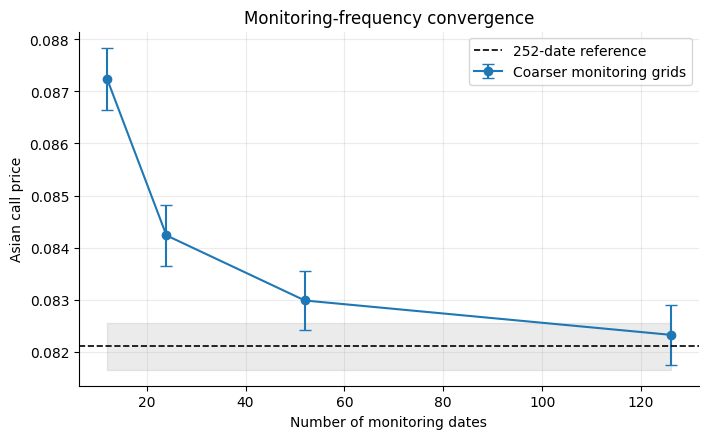

In [9]:
fig, ax = plt.subplots()
ax.errorbar(
    monitoring_df['n_monitoring'],
    monitoring_df['price_cv'],
    yerr=1.96 * monitoring_df['stderr_cv'],
    marker='o',
    capsize=4,
    label='Coarser monitoring grids',
)
ax.axhline(reference_cv['price'], color='black', linestyle='--', linewidth=1.2, label='252-date reference')
ax.fill_between(
    [monitoring_df['n_monitoring'].min(), monitoring_df['n_monitoring'].max()],
    reference_cv['price'] - 1.96 * reference_cv['stderr'],
    reference_cv['price'] + 1.96 * reference_cv['stderr'],
    color='black',
    alpha=0.08,
)
ax.set_xlabel('Number of monitoring dates')
ax.set_ylabel('Asian call price')
ax.set_title('Monitoring-frequency convergence')
ax.legend()
plt.show()


## 7. Strike sweep and shape checks

A realistic pricing extension should check more than one strike. The same simulated averages are reused across strikes, which makes monotonicity and convexity checks more meaningful because the payoff is evaluated pathwise on a shared sample.


In [10]:
strike_grid = np.linspace(0.70, 1.30, 13)
strike_rows = []
for k in strike_grid:
    raw = asian_price_raw(samples.arithmetic_average, float(k))
    cv = asian_price_with_average_control(samples.arithmetic_average, float(k), params.f0)
    euro = european_price_estimate(samples.terminal, float(k))
    strike_rows.append({
        'strike': float(k),
        'asian_price_raw': raw['price'],
        'asian_stderr_raw': raw['stderr'],
        'asian_price_cv': cv['price'],
        'asian_stderr_cv': cv['stderr'],
        'european_price': euro['price'],
        'european_stderr': euro['stderr'],
        'asian_minus_european': cv['price'] - euro['price'],
        'cv_stderr_reduction': cv['stderr_reduction'],
    })

strike_df = pd.DataFrame(strike_rows)
strike_df


,strike,asian_price_raw,asian_stderr_raw,asian_price_cv,asian_stderr_cv,european_price,european_stderr,asian_minus_european,cv_stderr_reduction
0,0.700000,0.309584,0.000618,0.309711,0.000115,0.344569,0.000933,-0.034858,5.353540
1,0.750000,0.264691,0.000593,0.264811,0.000138,0.304854,0.000897,-0.040043,4.295880
2,0.800000,0.221872,0.000563,0.221985,0.000161,0.267069,0.000857,-0.045084,3.508736
3,0.850000,0.181763,0.000527,0.181867,0.000181,0.231443,0.000815,-0.049576,2.914749
4,0.900000,0.145014,0.000485,0.145107,0.000197,0.198279,0.000769,-0.053172,2.460252
5,0.950000,0.112309,0.000437,0.112389,0.000207,0.167821,0.000721,-0.055432,2.110347
6,1.000000,0.084138,0.000385,0.084205,0.000209,0.140277,0.000672,-0.056072,1.838467
7,1.050000,0.060773,0.000332,0.060827,0.000204,0.115754,0.000621,-0.054927,1.626321
8,1.100000,0.042285,0.000279,0.042327,0.000191,0.094304,0.000571,-0.051976,1.462340
9,1.150000,0.028314,0.000230,0.028346,0.000172,0.075974,0.000522,-0.047628,1.335751


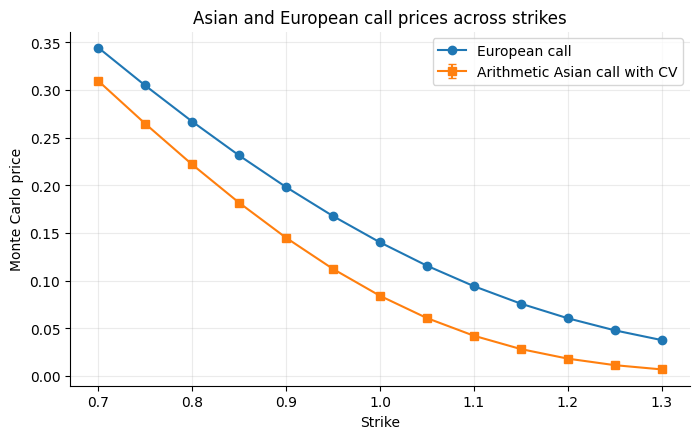

In [11]:
fig, ax = plt.subplots()
ax.plot(strike_df['strike'], strike_df['european_price'], marker='o', label='European call')
ax.errorbar(
    strike_df['strike'],
    strike_df['asian_price_cv'],
    yerr=1.96 * strike_df['asian_stderr_cv'],
    marker='s',
    capsize=3,
    label='Arithmetic Asian call with CV',
)
ax.set_xlabel('Strike')
ax.set_ylabel('Monte Carlo price')
ax.set_title('Asian and European call prices across strikes')
ax.legend()
plt.show()


## 8. Summary validation table

The checks below are intentionally numerical rather than cosmetic. They test whether the path-dependent extension keeps the properties that matter for using the paper algorithm outside the European benchmark setting.


In [12]:
asian_prices = strike_df['asian_price_cv'].to_numpy()
european_prices = strike_df['european_price'].to_numpy()
first_diff = np.diff(asian_prices)
second_diff = np.diff(asian_prices, n=2)

validation_rows = [
    {
        'check': 'single-step terminal samples match project simulator',
        'metric': float(single_step_check['max_abs_terminal_diff'].iloc[0]),
        'passed': bool(single_step_check['passed'].iloc[0]),
    },
    {
        'check': 'terminal samples are finite and nonnegative',
        'metric': float(np.min(samples.terminal)),
        'passed': bool(np.isfinite(samples.terminal).all() and np.all(samples.terminal >= 0.0)),
    },
    {
        'check': 'arithmetic averages are finite and nonnegative',
        'metric': float(np.min(samples.arithmetic_average)),
        'passed': bool(np.isfinite(samples.arithmetic_average).all() and np.all(samples.arithmetic_average >= 0.0)),
    },
    {
        'check': 'terminal martingale z-score within 3 standard errors',
        'metric': float(abs(terminal_diag['z_score'])),
        'passed': bool(abs(terminal_diag['z_score']) < 3.0),
    },
    {
        'check': 'average martingale z-score within 3 standard errors',
        'metric': float(abs(average_diag['z_score'])),
        'passed': bool(abs(average_diag['z_score']) < 3.0),
    },
    {
        'check': 'Asian prices decrease with strike',
        'metric': float(np.max(first_diff)),
        'passed': bool(np.all(first_diff <= 1e-12)),
    },
    {
        'check': 'Asian prices are convex in strike on the grid',
        'metric': float(np.min(second_diff)),
        'passed': bool(np.all(second_diff >= -1e-12)),
    },
    {
        'check': 'Asian prices are below same-path European prices',
        'metric': float(np.max(strike_df['asian_minus_european'])),
        'passed': bool(np.all(strike_df['asian_minus_european'] <= 3.0 * strike_df['asian_stderr_cv'])),
    },
    {
        'check': 'average control variate reduces Asian baseline stderr',
        'metric': float(asian_cv['stderr_reduction']),
        'passed': bool(asian_cv['stderr_reduction'] > 1.0),
    },
]

validation_summary = pd.DataFrame(validation_rows)
validation_summary


,check,metric,passed
0,single-step terminal samples match project sim...,0.000000,True
1,terminal samples are finite and nonnegative,0.000000,True
2,arithmetic averages are finite and nonnegative,0.165568,True
3,terminal martingale z-score within 3 standard ...,0.210507,True
4,average martingale z-score within 3 standard e...,0.209107,True
5,Asian prices decrease with strike,-0.004457,True
6,Asian prices are convex in strike on the grid,0.002073,True
7,Asian prices are below same-path European prices,-0.030739,True
8,average control variate reduces Asian baseline...,1.838467,True


## 9. Optional heavier configuration

The default notebook is sized to run quickly. For a paper-scale appendix, increase the path budgets below and rerun the monitoring convergence section. The code is disabled by default to keep this notebook practical during review.


In [13]:
RUN_HEAVY = False

if RUN_HEAVY:
    heavy_reference_paths = 300_000
    heavy_grid_paths = 200_000
    heavy_reference_contract = AsianContract(
        maturity=contract.maturity,
        strike=contract.strike,
        n_monitoring=504,
        include_initial=contract.include_initial,
    )
    print('Suggested heavy setup:')
    print('reference_paths =', heavy_reference_paths)
    print('grid_paths =', heavy_grid_paths)
    print('reference_monitoring =', heavy_reference_contract.n_monitoring)
else:
    print('Heavy run skipped. Set RUN_HEAVY = True to print the paper-scale settings.')


Heavy run skipped. Set RUN_HEAVY = True to print the paper-scale settings.


## Conclusion

This extension is useful because it tests the SABR simulation scheme in the setting where Monte Carlo is actually needed: a path-dependent payoff with many monitoring dates.

The numerical evidence above supports four practical conclusions:

1. the Asian path simulator is consistent with the existing terminal SABR simulator in the one-step case;
2. the simulated terminal forward and arithmetic average remain close to their martingale expectation $F_0$;
3. the average-control-variate estimator materially reduces standard error without changing the model;
4. monitoring-frequency convergence is visible and can be measured against a fine-grid Monte Carlo proxy.

The main remaining limitation is benchmark availability. Unlike European calls, arithmetic Asian SABR prices do not have a simple FDM table in the paper, so the fine-grid Monte Carlo reference should be treated as an internal numerical benchmark rather than an external truth.
